### Gradient Descent

**A type of optimization techniques where one move towards the minimum in an iterative manner**
And what is it trying to optimizer.. ?? The loss (cost) function.

### Steps Involved

1) Guess a point (randomly or through some techniques)
2) Choose a step size which in deep learning is called the learning rate `(ρ) rho` and is also one of the most important hyperparameter in deep learning.
3) Calculate the gradient of the function.
4) Move in opposite   direction by substracting this from the initial guess. This is because we want to descend and gradient gives the steepst ascent direction.

5) Repeat steps 3 and 4 for n times or until a stop criterion is reached.

In equation from for deep learning applications it can be written as

$$
\beta_{\text{new}}
=
\beta_{\text{old}}
+
\rho \, \frac{\partial \mathrm{Err}}{\partial \beta}
$$




ρ is the learning rate and governs how much you dampen the gradient value while taking the step.

β is a network parameter.

* One more point to mention here is that unless the function is convex the algorithm can get stuck at a local minimum instead of converging to the global minimum.



### In summary, the gradient descent is an optimization method that finds the minimum of an objective function by incrementally updating its parameters in the negative direction of the gradient of the function which is the direction of steepest descent.


## Gradient Descent 1D Example

Let we look at the eg: for the 1D data , since it is the easiest to visualize .

Here we use the equation.

$$
\begin{aligned}
y &= x^4 + x^3 - 6x^2 \\
\frac{dy}{dx} &= 4x^3 + 3x^2 - 12x
\end{aligned}
$$

Here is the manual implementation of the code using python ,,..............

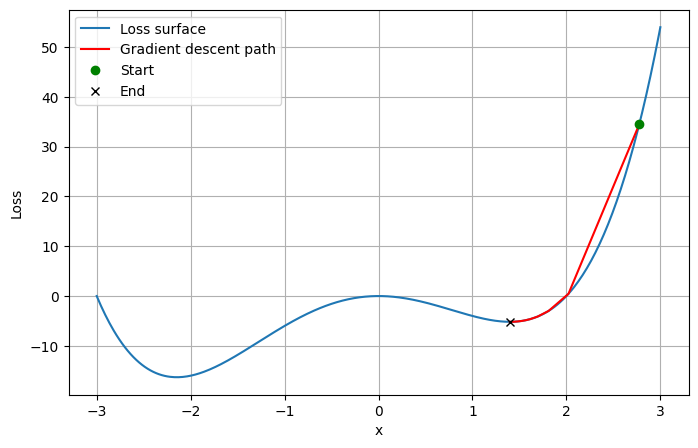

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Loss function
def loss_surface(x):
    return x**4 + x**3 - 6*x**2

# Gradient of the loss
def loss_grad(x):
    return 4*x**3 + 3*x**2 - 12*x

# Create x range for plotting
x = np.linspace(-3, 3, 400)
y = loss_surface(x)

# Random start point
x0 = np.random.uniform(-3, 3)

lr = 0.01  # learning rate
steps = 100

# Store trajectory
x_path = [x0]

# Gradient descent loop
for _ in range(steps):
    x0 = x0 - lr * loss_grad(x0)
    x_path.append(x0)

x_path = np.array(x_path)
y_path = loss_surface(x_path)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label="Loss surface")
plt.plot(x_path, y_path, 'r-', label="Gradient descent path")
plt.plot(x_path[0], y_path[0], 'go', label="Start")
plt.plot(x_path[-1], y_path[-1], 'kx', label="End")
plt.xlabel("x")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Gradinet Descent 2D eg:

Here we use the paraboloid and its equation is as follows:
$$
\begin{aligned}
f(x, y) &= (x - 2)^2 + (y - 2)^2 \\
\frac{\partial f}{\partial x} &= 2(x - 2) \\
\frac{\partial f}{\partial y} &= 2(y - 2)
\end{aligned}
$$


$$
\nabla f(x, y) =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
2(x - 2) \\
2(y - 2)
\end{bmatrix}
$$


we use sympony for here : it allows to do symbolic computations on equations. Even we don't calculus (but we do!)


Following code creates a function f1 using the symbolic representation of sympy and calculates the partial derivatives w.r.t. x and y to calculate the gradient. Which is then used to perform gradient descent by updating the x and y values using the appropriate components.

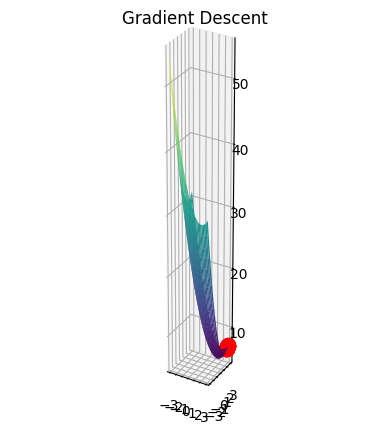

In [ ]:

#import the libraries
from mpl_toolkits import mplot3d
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, lambdify


# Define the sympy symbols to be used in the function
x = symbols('x')
y = symbols('y')
#Define the function in terms of x and y
f1 = (x-2) ** 2 + (y-2)**2+5

# Calculate the partial derivatives of f1 w.r.t. x and y
f1x = diff(f1,x)
f1y = diff(f1,y)

# Define a function optimized for numpy array calculation
# in sympy
f = lambdify([x,y],f1,'numpy')

# Define the x and y grid arrays
x_grid = np.linspace(-3, 3, 30)
y_grid = np.linspace(-3, 3, 30)
# Create mesh grid for surface plot
X, Y = np.meshgrid(x_grid,y_grid)

#Define the surface function using the lambdify function
Z = f(X,Y)

#Select a start point
x0,y0 = (3,3)
#Initialize a list for storing the gradient descent points
xlist = [x0]
ylist = [y0]

#Specify the learning rate
lr=0.001

#Perform gradient descent
for i in range(100):
    # Update the x and y values using the negative gradient values
    x0-=f1x.evalf(subs={x:x0,y:y0})*lr
    y0-=f1y.evalf(subs={x:x0,y:y0})*lr
    # Append to the list to keep track of the points
    xlist.append(x0)
    ylist.append(y0)

xarr = np.array(xlist,dtype='float64')
yarr = np.array(ylist,dtype='float64')
zlist = list(f(xarr,yarr))

#Plot the surface and points
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
# ax.plot(xlist,ylist,zlist,markerfacecolor='r', markeredgecolor='r', marker='o', markersize=10, alpha=0.6)
ax.plot(xlist,ylist,zlist,'ro',markersize=10,alpha=0.6)
ax.set_title('Gradient Descent');
ax.set_aspect('equal')

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install (PyQt5, PySide2)'


** The Grad: Descent can be classified as following categories**
* Stochastic Gradient Descent
* Mini-Batch Gradient Descent
* Batch Gradient Descent

#### Storchastic Gradient Descent
Suppose we want to minimize an objective function that is written as a sum of differentiable functions.

$$
Q(w) = \sum_{i=1}^{N} Q_i(w)

$$

Each term Qᵢ is usually associated with the iᵗʰ data point.

Standard gradient descent (batch gradient descent) is given as follows.
$$
w = w - \eta \, \nabla Q{w} = w - \eta\sum_{i=1}^N Q_i{w}
$$

where $$ \eta$$ is the learning rate (step size) .

### Stochastic Gradient Descent:
Considers only a subset of summarized functions at every iteration. This can be effective for large-scaled problems. The Gradient of Q(W) is approximated by a gradient at a single example.

$$ w = w - \eta \, \nabla Q_i{w} $$

This update needs to be done for each training example. Several passes might be necessary over the training set until the algorithm converges.

Pueudo-code for SGD:

* Choose an intitial value of w and $$ \eta $$
* Reapeat until converged
* Randomly shuffle data points in the training set.

* For i = 1, 2, 3, ...., n do:
*$$ w = w - \eta \, \nabla Q_i{w} $$





LLet us consider the following equation:
$$
y = w_1 + w_2 x
$$

The objective function is:
$$
Q(w) = \sum_{i=1}^{N} Q_i(w)
     = \sum_{i=1}^{N} \bigl(w_1 + w_2 x_i - y_i\bigr)^2
$$

The update rule of SGD then is as follows:
$$
\frac{\partial Q_i}{\partial w_1}
= 2 \bigl(w_1 + w_2 x_i - y_i\bigr)
$$

$$
\frac{\partial Q_i}{\partial w_2}
= 2 x_i \bigl(w_1 + w_2 x_i - y_i\bigr)
$$


**Mini Batch Gradient Descent**
* Batch Grad: Descent used all **n data points** in ecah iteration
* **Stochastic gradient descent** uses **1 data point** in each iteration
* **Mini_Batch Gradient Descent** used **b data points** in each iteration , **b** is the parameter called mini batch size

Psudo code for Mini-Batch Gradient Descent

* Choose an intial value of  w and  η.

* Choose for example b = 10
* Repeat unill converged
* Randomly shuffle data points in the training set.

for i = i , 11, 21, ..., n-9 do:

$$ w = w - \eta  \sum_{k=i}^{i+9}  \nabla Q_i{w} $$

Few points on the three variants.
* SGD is noiser than the other varaiant because it is updated per example

* SGD is often called an online ML algorithm as it updates the model for each training example.
* SGD is computationlly more expensive than  the other variants because it per example
* SGD is jittery and cause convergence to a minimum difficult.
* Mini-batch gradient allows to take the advantage og the GPU and process multiple examples in one go therefore reducing the training time.
* Batch gradient descent is practically infeasible unless we have a small data-set which can fit into the available memory.


Choice of mini-batch size parameter b depends on your GPU, data-set and the model. A rule of thumb is to choose a size in multiples of 8. Generally, 32 is a good number to start with. If you choose your number too high or low then the algorithm can become slower. In the former case, computations could become slower because you are putting a lot of load on the GPU. While in the latter case, lower mini-batch size underutilizes your GPU. Finding the right balance for your case is important.


If η is too high, the algorithm diverges. If η is too low, it makes the algorithm slow to converge.
A common practice is to make ηₙ a decreasing function of iteration number n. Following are two examples.

* ηₙ = k/(n+c) , where k and c are constants.
* ηₙ = η₀ e⁻ᵏⁿ, where η₀ is the initial learning rate and k decides the steepness of the exponential decay.

